In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

## Fitted parameter results vs sub-band configuration (nsub_in, nsub_out)

In [2]:
nsub_in = [10, 10, 16, 16, 20, 20, 20, 20, 40, 40, 40, 80, 80, 80, 80, 80, 16, 40, 80, 80, 16, 40 , 40]
nsub_out = [4, 8, 4, 16, 4, 8, 12, 16, 8, 38, 40, 4, 12, 16, 40, 80, 12, 4, 60, 8, 8, 16, 12]

print(len(nsub_in), len(nsub_out))

data = {
    'QUBIC':                        [(-0.008, 0.054), (0.000, 0.043), (-0.005, 0.034), (-0.002, 0.030), (-0.011, 0.043), (0.003, 0.039), (-0.006, 0.034), (-0.003, 0.035), (-0.000, 0.035), (-0.005, 0.028), (-0.002, 0.030), (-0.014, 0.043),  (-0.007, 0.032), (0.003, 0.023), (-0.005, 0.031), (-0.009, 0.029), (-0.012, 0.035), (-0.005, 0.036), (-0.006, 0.030), (-0.011, 0.044), (-0.000, 0.044), (-0.002, 0.032), (-0.011, 0.033)],
    'QUBIC + Planck (143+217+353)': [(-0.011, 0.021), (-0.006, 0.017), (-0.010, 0.012), (0.004, 0.013), (-0.007, 0.017), (-0.004, 0.015), (-0.011, 0.016), (-0.004, 0.016), (-0.002, 0.016), (-0.005, 0.013), (-0.005, 0.013), (-0.003, 0.019), (-0.003, 0.014), (0.001, 0.011), (-0.002, 0.012), (-0.005, 0.012), (-0.009, 0.015), (-0.003, 0.016), (-0.005, 0.013), (-0.015, 0.017), (0.004, 0.020), (0.003, 0.012), (-0.006, 0.015)],
}

print(len(data["QUBIC"]), len(data["QUBIC + Planck (143+217+353)"]))

def fmt(val, err):
    return f'{val:+.3f} ± {err:.3f}'

rows = []
for i, (ni, no) in enumerate(zip(nsub_in, nsub_out)):
    rows.append({
        'nsub_in': ni,
        'nsub_out': no,
        **{cfg: fmt(*data[cfg][i]) for cfg in data}
    })

df = pd.DataFrame(rows).set_index(['nsub_in', 'nsub_out'])

df.style \
    .set_caption('Fitted parameter (r ± σ) for different sub-band configurations') \
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '13px'), ('font-weight', 'bold'), ('text-align', 'left'), ('padding-bottom', '6px')]},
        {'selector': 'th',      'props': [('background-color', '#2c3e50'), ('color', 'white'), ('padding', '6px 14px'), ('text-align', 'center')]},
        {'selector': 'td',      'props': [('padding', '5px 14px'), ('text-align', 'center'), ('font-family', 'monospace')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', "#f0f4f800")]},
    ])

23 23
23 23


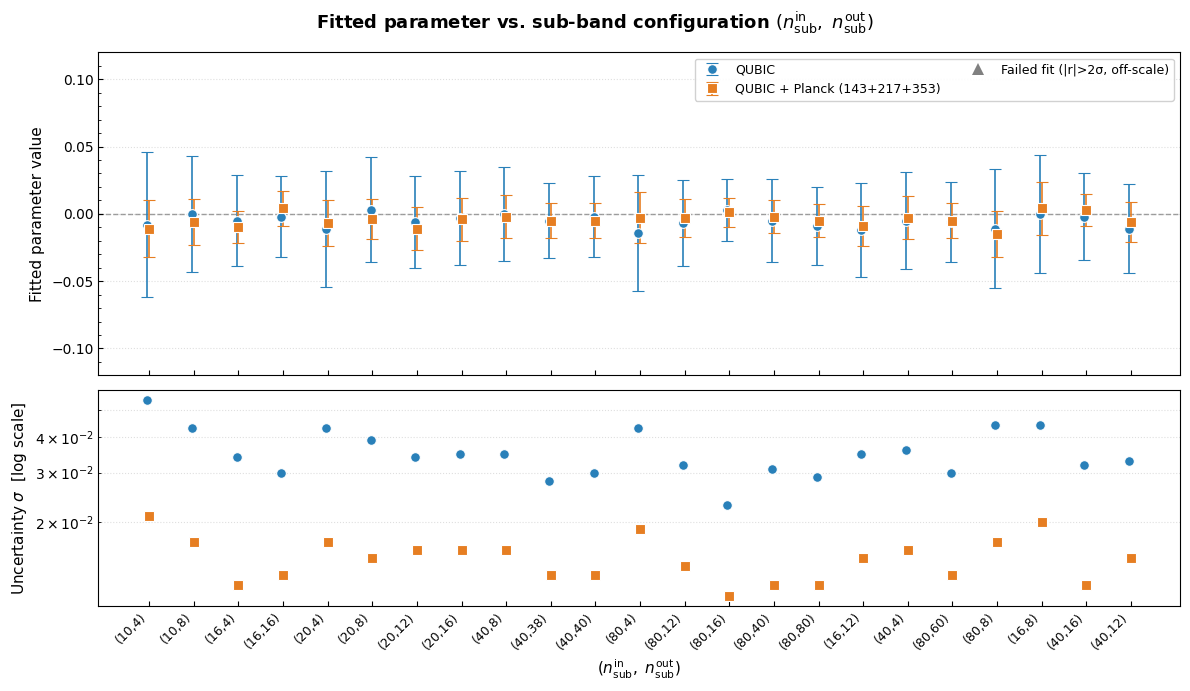

In [3]:
from matplotlib.lines import Line2D

NSIGMA = 2  # consistency threshold: fail if |val| > NSIGMA * err

def is_failed(val, err):
    if err == 0:
        return True           # hit prior boundary
    return abs(val) / err > NSIGMA

configs = list(data.keys())
colors  = ['#2980b9', '#e67e22', '#27ae60']
markers = ['o', 's', '^']
offsets = [-0.04, 0.0, 0.04]

x_positions = np.arange(len(nsub_in))
x_labels = [f'({ni},{no})' for ni, no in zip(nsub_in, nsub_out)]

fig, (ax_val, ax_sig) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                                      gridspec_kw={'height_ratios': [3, 2]})
fig.subplots_adjust(hspace=0.08)

# Value panel: zoom on converged region
YLIM = 0.12

ax_val.axhline(0, color='black', lw=1, ls='--', alpha=0.4, zorder=1)

for cfg, col, mk, off in zip(configs, colors, markers, offsets):
    vals = np.array([v for v, _ in data[cfg]])
    errs = np.array([e for _, e in data[cfg]])
    ok   = np.array([not is_failed(v, e) for v, e in data[cfg]])
    x    = x_positions + off

    if ok.any():
        ax_val.errorbar(x[ok], vals[ok], yerr=errs[ok],
                        fmt=mk, color=col, label=cfg,
                        capsize=4, capthick=1.2, elinewidth=1.2,
                        markersize=7, markeredgewidth=0.8, markeredgecolor='white', zorder=3)

    for j in np.where(~ok)[0]:
        v  = vals[j]
        xi = x[j]
        at_top = v > 0
        y_edge = YLIM * 0.92 if at_top else -YLIM * 0.92
        tri    = '^' if at_top else 'v'
        ax_val.plot(xi, y_edge, marker=tri, color=col, markersize=11,
                    markeredgewidth=0, zorder=4, clip_on=False)
        ax_val.text(xi, y_edge + (0.013 if at_top else -0.013),
                    f'{v:+.3f}', ha='center',
                    va='bottom' if at_top else 'top',
                    fontsize=7.5, color=col, fontweight='bold')

ax_val.set_ylim(-YLIM, YLIM)
ax_val.set_ylabel('Fitted parameter value', fontsize=11)
ax_val.tick_params(direction='in', which='both')
ax_val.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax_val.grid(axis='y', which='major', ls=':', alpha=0.4)

handles, labels = ax_val.get_legend_handles_labels()
extra = [
    Line2D([0], [0], marker='^', color='grey', ls='none', markersize=9,
           markeredgewidth=0, label=f'Failed fit (|r|>{NSIGMA}σ, off-scale)'),
]
ax_val.legend(handles + extra, labels + [h.get_label() for h in extra],
              framealpha=0.9, fontsize=9, ncol=2, loc='upper right')

# Sigma panel
for cfg, col, mk, off in zip(configs, colors, markers, offsets):
    vals = np.array([v for v, _ in data[cfg]])
    errs = np.array([e for _, e in data[cfg]])
    ok   = np.array([not is_failed(v, e) for v, e in data[cfg]])
    x    = x_positions + off

    if ok.any():
        ax_sig.plot(x[ok], errs[ok], mk, color=col, markersize=7,
                    markeredgewidth=0.8, markeredgecolor='white', zorder=3)
    if (~ok).any():
        ax_sig.plot(x[~ok], np.where(errs[~ok] > 0, errs[~ok], 1e-4),
                    marker='x', color=col, ls='none',
                    markersize=11, markeredgewidth=2.5, zorder=4)

ax_sig.set_yscale('log')
ax_sig.set_xticks(x_positions)
ax_sig.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=9)
ax_sig.set_xlabel(r'$(n_{\mathrm{sub}}^{\mathrm{in}},\ n_{\mathrm{sub}}^{\mathrm{out}})$', fontsize=11)
ax_sig.set_ylabel(r'Uncertainty $\sigma$  [log scale]', fontsize=11)
ax_sig.tick_params(direction='in', which='both', axis='both')
ax_sig.grid(axis='y', which='both', ls=':', alpha=0.4)

fig.suptitle(r'Fitted parameter vs. sub-band configuration $(n_{\mathrm{sub}}^{\mathrm{in}},\ n_{\mathrm{sub}}^{\mathrm{out}})$',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig('fitted_param_vs_nsub.png', dpi=150, bbox_inches='tight')
plt.show()


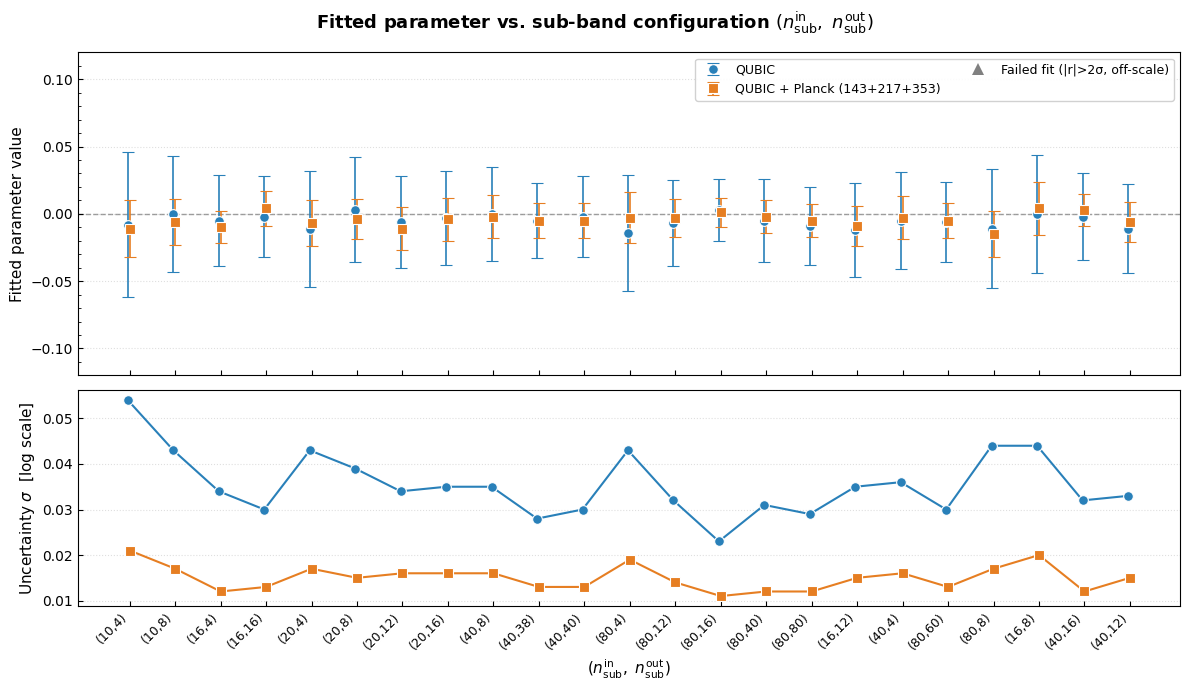

In [4]:
fig, (ax_val, ax_sig) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                                      gridspec_kw={'height_ratios': [3, 2]})
fig.subplots_adjust(hspace=0.08)

ax_val.axhline(0, color='black', lw=1, ls='--', alpha=0.4, zorder=1)

for cfg, col, mk, off in zip(configs, colors, markers, offsets):
    vals = np.array([v for v, _ in data[cfg]])
    errs = np.array([e for _, e in data[cfg]])
    ok   = np.array([not is_failed(v, e) for v, e in data[cfg]])
    x    = x_positions + off

    if ok.any():
        ax_val.errorbar(x[ok], vals[ok], yerr=errs[ok],
                        fmt=mk, color=col, label=cfg,
                        capsize=4, capthick=1.2, elinewidth=1.2,
                        markersize=7, markeredgewidth=0.8, markeredgecolor='white', zorder=3)

    for j in np.where(~ok)[0]:
        v  = vals[j]
        xi = x[j]
        at_top = v > 0
        y_edge = YLIM * 0.92 if at_top else -YLIM * 0.92
        tri    = '^' if at_top else 'v'
        ax_val.plot(xi, y_edge, marker=tri, color=col, markersize=11,
                    markeredgewidth=0, zorder=4, clip_on=False)
        ax_val.text(xi, y_edge + (0.013 if at_top else -0.013),
                    f'{v:+.3f}', ha='center',
                    va='bottom' if at_top else 'top',
                    fontsize=7.5, color=col, fontweight='bold')

ax_val.set_ylim(-YLIM, YLIM)
ax_val.set_ylabel('Fitted parameter value', fontsize=11)
ax_val.tick_params(direction='in', which='both')
ax_val.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax_val.grid(axis='y', which='major', ls=':', alpha=0.4)

handles, labels = ax_val.get_legend_handles_labels()
extra = [
    Line2D([0], [0], marker='^', color='grey', ls='none', markersize=9,
           markeredgewidth=0, label=f'Failed fit (|r|>{NSIGMA}σ, off-scale)'),
]
ax_val.legend(handles + extra, labels + [h.get_label() for h in extra],
              framealpha=0.9, fontsize=9, ncol=2, loc='upper right')

# Sigma panel
for cfg, col, mk, off in zip(configs, colors, markers, offsets):
    vals = np.array([v for v, _ in data[cfg]])
    errs = np.array([e for _, e in data[cfg]])
    ok   = np.array([not is_failed(v, e) for v, e in data[cfg]])
    x    = x_positions + off

    if ok.any():
        ax_sig.plot(x[ok], errs[ok], mk + '-', color=col, markersize=7,
                    markeredgewidth=0.8, markeredgecolor='white', zorder=3)
    if (~ok).any():
        ax_sig.plot(x[~ok], np.where(errs[~ok] > 0, errs[~ok], 1e-4),
                    marker='x', color=col, ls='none',
                    markersize=11, markeredgewidth=2.5, zorder=4)

# ax_sig.set_yscale('log')
ax_sig.set_xticks(x_positions)
ax_sig.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=9)
ax_sig.set_xlabel(r'$(n_{\mathrm{sub}}^{\mathrm{in}},\ n_{\mathrm{sub}}^{\mathrm{out}})$', fontsize=11)
ax_sig.set_ylabel(r'Uncertainty $\sigma$  [log scale]', fontsize=11)
ax_sig.tick_params(direction='in', which='both', axis='both')
ax_sig.grid(axis='y', which='both', ls=':', alpha=0.4)

fig.suptitle(r'Fitted parameter vs. sub-band configuration $(n_{\mathrm{sub}}^{\mathrm{in}},\ n_{\mathrm{sub}}^{\mathrm{out}})$',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig('fitted_param_vs_nsub_alt.png', dpi=150, bbox_inches='tight')
plt.show()


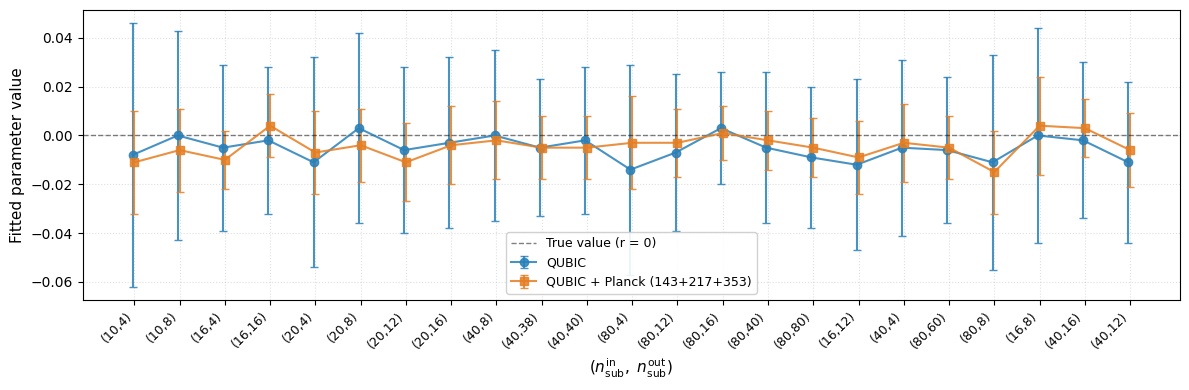

In [5]:
# Simple comparison plot
fig, ax = plt.subplots(figsize=(12, 4))

for cfg, col, mk, off in zip(configs, colors, markers, offsets):
    vals = np.array([v for v, _ in data[cfg]])
    errs = np.array([e for _, e in data[cfg]])
    ax.errorbar(x_positions + off, vals, yerr=errs,
                fmt=mk+'-', color=col, label=cfg,
                capsize=3, markersize=6, alpha=0.85)

ax.axhline(0, color='black', lw=1, ls='--', alpha=0.5, label='True value (r = 0)')
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=9)
ax.set_xlabel(r'$(n_{\mathrm{sub}}^{\mathrm{in}},\ n_{\mathrm{sub}}^{\mathrm{out}})$', fontsize=11)
ax.set_ylabel('Fitted parameter value', fontsize=11)
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(ls=':', alpha=0.4)
fig.tight_layout()
plt.show()


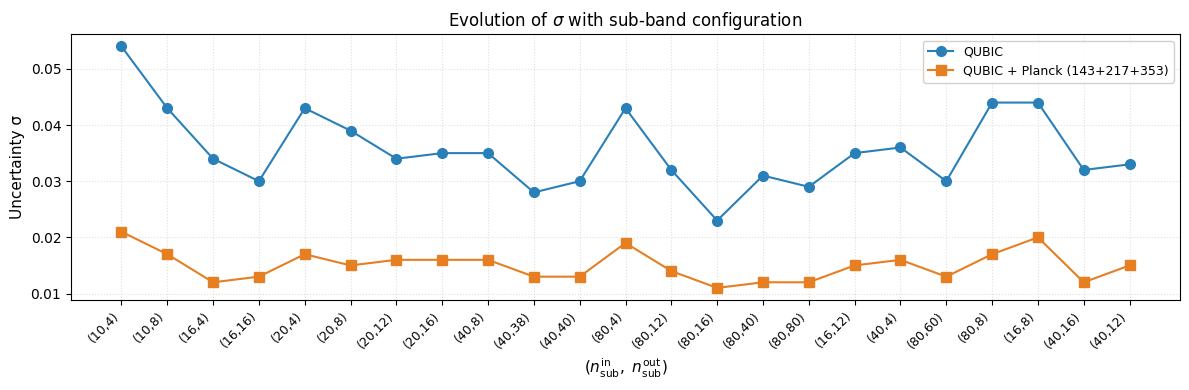

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))

for cfg, col, mk in zip(configs, colors, markers):
    errs = np.array([e for _, e in data[cfg]])
    ax.plot(x_positions, errs, mk+'-', color=col, label=cfg, markersize=7)

# ax.set_yscale('log')
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=9)
ax.set_xlabel(r'$(n_{\mathrm{sub}}^{\mathrm{in}},\ n_{\mathrm{sub}}^{\mathrm{out}})$', fontsize=11)
ax.set_ylabel('Uncertainty σ', fontsize=11)
ax.set_title(r'Evolution of $\sigma$ with sub-band configuration', fontsize=12)
ax.grid(ls=':', alpha=0.4)
ax.legend(fontsize=9, framealpha=0.9)

fig.tight_layout()
plt.show()


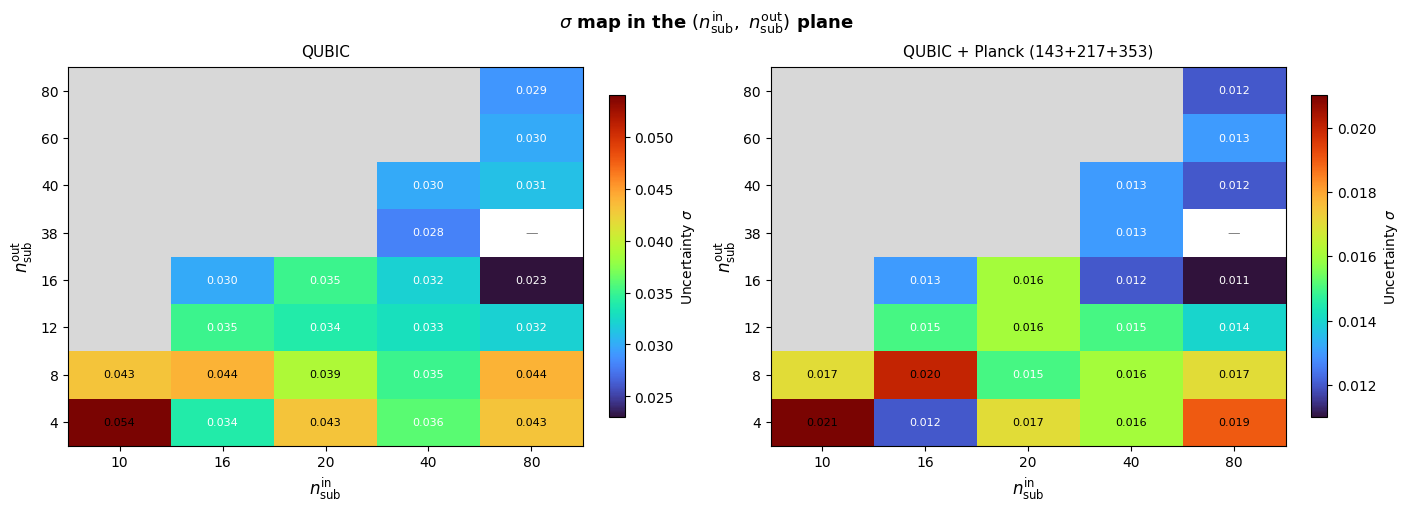

In [7]:
# 2D heatmap: nsub_in vs nsub_out, colorbar = sigma
unique_in  = sorted(set(nsub_in))
unique_out = sorted(set(nsub_out))

idx_in  = {v: i for i, v in enumerate(unique_in)}
idx_out = {v: i for i, v in enumerate(unique_out)}

fig, axes = plt.subplots(1, len(configs), figsize=(7 * len(configs), 5),
                          constrained_layout=True)
if len(configs) == 1:
    axes = [axes]

for ax, cfg in zip(axes, configs):
    grid = np.full((len(unique_out), len(unique_in)), np.nan)
    for i, (ni, no) in enumerate(zip(nsub_in, nsub_out)):
        _, err = data[cfg][i]
        if err > 0:
            grid[idx_out[no], idx_in[ni]] = err

    # Mask upper triangle: nsub_out > nsub_in
    for row, no in enumerate(unique_out):
        for col, ni in enumerate(unique_in):
            if no > ni:
                grid[row, col] = np.nan

    vmin = np.nanmin(grid)
    vmax = np.nanmax(grid)
    im = ax.imshow(grid, origin='lower', aspect='auto',
                   cmap='turbo', vmin=vmin, vmax=vmax,
                   extent=[-0.5, len(unique_in) - 0.5,
                            -0.5, len(unique_out) - 0.5])

    # Grey out invalid (upper triangle) cells
    invalid = np.zeros((len(unique_out), len(unique_in), 4))
    for row, no in enumerate(unique_out):
        for col, ni in enumerate(unique_in):
            if no > ni:
                invalid[row, col] = [0.85, 0.85, 0.85, 1.0]
    ax.imshow(invalid, origin='lower', aspect='auto',
              extent=[-0.5, len(unique_in) - 0.5,
                       -0.5, len(unique_out) - 0.5])

    # Annotate each valid cell
    for row, no in enumerate(unique_out):
        for col, ni in enumerate(unique_in):
            if no > ni:
                continue
            val = grid[row, col]
            if not np.isnan(val):
                ax.text(col, row, f'{val:.3f}', ha='center', va='center',
                        fontsize=8, color='white' if val < (vmin + vmax) / 2 else 'black')
            else:
                ax.text(col, row, '—', ha='center', va='center',
                        fontsize=9, color='grey')

    ax.set_xticks(range(len(unique_in)))
    ax.set_xticklabels(unique_in)
    ax.set_yticks(range(len(unique_out)))
    ax.set_yticklabels(unique_out)
    ax.set_xlabel(r'$n_{\mathrm{sub}}^{\mathrm{in}}$', fontsize=12)
    ax.set_ylabel(r'$n_{\mathrm{sub}}^{\mathrm{out}}$', fontsize=12)
    ax.set_title(cfg, fontsize=11, pad=8)

    cb = fig.colorbar(im, ax=ax, shrink=0.85)
    cb.set_label(r'Uncertainty $\sigma$', fontsize=10)

fig.suptitle(r'$\sigma$ map in the $(n_{\mathrm{sub}}^{\mathrm{in}},\ n_{\mathrm{sub}}^{\mathrm{out}})$ plane',
             fontsize=13, fontweight='bold')
plt.savefig('sigma_2d_map.png', dpi=150, bbox_inches='tight')
plt.show()
